In [1]:
import random
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scanorama

import timeit
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
from CellPos.preprocessing import preprocess
from CellPos.train import SpaceReconstructor, evaluate

## Date Processing

In [3]:
sc_obj = sc.read_h5ad("/.../data/Mouse_Embryo/E2z2/sc_adata_E2z2.h5ad")
st_obj = sc.read_h5ad("/.../data/Mouse_Embryo/E2z2/st_adata_E2z2.h5ad")
label_encoder = LabelEncoder()
st_obj.obs['label'] = label_encoder.fit_transform(st_obj.obs['cluster']) 

In [4]:
sc_adata, st_adata = preprocess(sc_adata=sc_obj, st_adata=st_obj,
                                sc_min_genes = 50, sc_min_cells = 5,
                                st_min_genes = 50, st_min_cells = 5,
                                hvg_features=351, svg_features=351,  
                                select_gene='union') # select_hvg='union' or 'intersection'

sc_adata: AnnData object with n_obs × n_vars = 7162 × 351
    obs: 'cell', 'celltype', 'cluster', 'n_genes'
    var: 'gene', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    obsm: 'spatial', 'spatial_centered', 'spatial_normalized'
st_adata: AnnData object with n_obs × n_vars = 504 × 351
    obs: 'cell', 'cluster', 'label', 'n_genes'
    var: 'gene', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'spatial_neighbors', 'moranI'
    obsm: 'spatial', 'spatial_centered', 'spatial_normalized'
    obsp: 'spatial_connectivities', 'spatial_distances'
Data have been pre-processed!


## Training

In [5]:
reconstructor = SpaceReconstructor(device='cuda:1', seed=2026)
p_config = {'encoder': {'dropout': [0.2, 0, 0]},
             'decoder': {'dropout': [0.2, 0, 0]},
             'pred': {'dropout': [0.3, 0.3, 0]}}
sc_adata, st_adata, m_sc, m_st, m_p = reconstructor.fit(sc_adata, st_adata, 
                                                        pretrain_epoch_num=2000, 
                                                        fulltrain_epoch_num=2000,
                                                        custom_config=p_config,)

--- Phase 1: Pre-training ---


embedding_pretrain:  25%|█▊     | 505/2000 [00:18<00:52, 28.29it/s, loss=1.0162]

Epoch [500/2000], Loss: 1.0368


embedding_pretrain:  50%|███   | 1003/2000 [00:35<00:35, 28.27it/s, loss=0.9436]

Epoch [1000/2000], Loss: 0.9577


...

Epoch [1000/2000], Loss: 0.2723


full_training:  75%|████████▎  | 1501/2000 [01:45<00:46, 10.84it/s, loss=0.2689]

Epoch [1500/2000], Loss: 0.2683


full_training: 100%|███████████| 2000/2000 [02:27<00:00, 13.54it/s, loss=0.2654]


Epoch [2000/2000], Loss: 0.2654
Total time: 221.27s


## Evaluating

In [6]:
sc_adata.obs['cluster_pred'] = label_encoder.inverse_transform(sc_adata.obs['label_pred'])
evaluate(sc_adata, compute_jsd_flag=True, label_col='celltype')

100%|██████████████████████████████████████| 7162/7162 [00:46<00:00, 153.48it/s]


For PCC: 1.0000,  PCC of pair distance: 0.9260
MSE: 146.0916,  MAE: 7.2761(±12.6660 SD)
Hit_rate (10-20-50-100): 1, 3, 12, 34
Adjusted Rand Index (ARI_sc): 0.8735
Average JSD: 0.1696
--- Detailed JSD per Cell Type ---
                                 Avg_JSD
Forebrain/Midbrain/Hindbrain    0.068509
NMP                             0.104601
Spinal cord                     0.115371
Gut tube                        0.151722
Allantois                       0.152135
Cardiomyocytes                  0.163492
Intermediate mesoderm           0.178448
Cranial mesoderm                0.183769
Mixed mesenchymal mesoderm      0.195957
Blood progenitors               0.204755
Dermomyotome                    0.211297
Anterior somitic tissues        0.212645
Sclerotome                      0.224643
Splanchnic mesoderm             0.235333
Neural crest                    0.282642
Surface ectoderm                0.289116
Haematoendothelial progenitors  0.293552
Definitive endoderm             0.328163
End

## Visualization 

In [8]:
colors = ["#972D36","#C55645","#D4A55B","#C6B598","#0C4E9B","#638DEE","#5F97C6","#8FDBF3",
          "#734E9C","#6D65A3","#9999CC","#C6C3E1","#2E8A57","#03C088","#BCD896","#BEEFBF",
          "#F38B2F","#F1B543","#F7BF6C","#FBDF9D","#E11E25","#DB6C76","#EE9094","#F2CDCF",] # Mouse Embryo

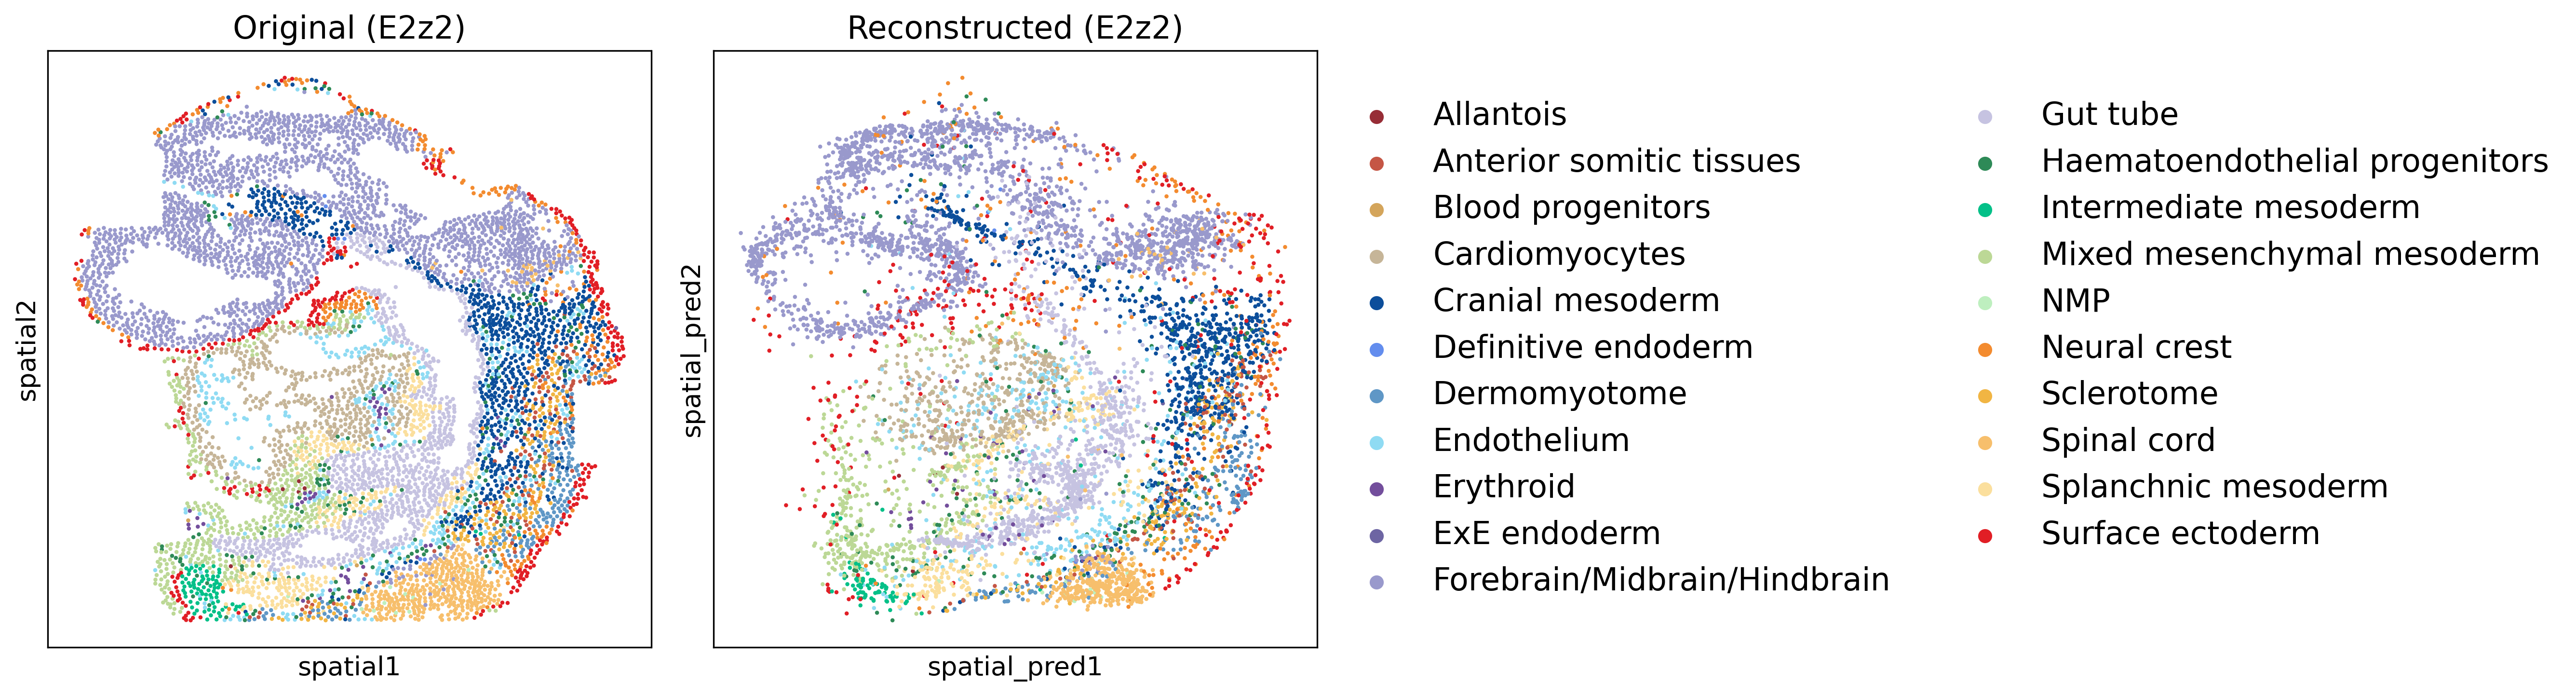

In [9]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 13
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plt.sca(axes[0])
sc.pl.embedding(sc_adata, basis='spatial', color='celltype', palette = colors, title='Original (E2z2)',
                show=False, legend_loc=None, ax=axes[0]) # basis='spatial_normalized'
plt.sca(axes[1])
sc.pl.embedding(sc_adata, basis='spatial_pred', color='celltype', palette = colors, title='Reconstructed (E2z2)',
                legend_fontsize='large', show=False, ax=axes[1])
plt.tight_layout()
plt.show()

## Data saving

In [10]:
import os
output_dir = "/.../cellPos_analysis/Mouse_Embryo/E2z2"
os.makedirs(output_dir, exist_ok=True)
sc_adata.write(f"{output_dir}/sc_E2z2.h5ad")
st_adata.write(f"{output_dir}/st_E2z2.h5ad")

In [11]:
import torch
sc_embed_model_save_path = os.path.join(output_dir, 'sc_E2z2_embed_model.pth')
st_embed_model_save_path = os.path.join(output_dir, 'st_E2z2_embed_model.pth')
pred_model_save_path = os.path.join(output_dir, 'sc_E2z2_pred_model.pth')
torch.save(m_sc, sc_embed_model_save_path) 
torch.save(m_st, st_embed_model_save_path) 
torch.save(m_p, pred_model_save_path) 